<a href="https://colab.research.google.com/github/Anakha10/northstar-analytics/blob/main/NorthStar_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

deliveries = pd.read_csv("deliveries.csv")
complaints = pd.read_csv("complaints.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
hubs = pd.read_csv("hubs.csv")
customers = pd.read_csv("customers.csv")

print(deliveries.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1             

In [12]:
print("Deliveries:", deliveries.shape)
print("Complaints:", complaints.shape)
print("Drivers:", drivers.shape)
print("Vehicles:", vehicles.shape)
print("Hubs:", hubs.shape)
print("Customers:", customers.shape)

Deliveries: (950, 13)
Complaints: (320, 10)
Drivers: (170, 8)
Vehicles: (120, 8)
Hubs: (8, 5)
Customers: (650, 9)


In [13]:
datasets = {
    "deliveries": deliveries,
    "complaints": complaints,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "customers": customers
}

for name, data in datasets.items():
    print("\n", name.upper())
    print("Rows before duplicate removal:", data.shape[0])
    data.drop_duplicates(inplace=True)
    print("Rows after duplicate removal:", data.shape[0])
    print("Missing values:")
    print(data.isnull().sum())


 DELIVERIES
Rows before duplicate removal: 950
Rows after duplicate removal: 950
Missing values:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

 COMPLAINTS
Rows before duplicate removal: 320
Rows after duplicate removal: 320
Missing values:
complaint_id            0
customer_id             0
order_id                0
complaint_type          0
channel                 0
severity                0
created_at              0
status                  0
resolution_days         0
compensation_amount    16
dtype: int64

 DRIVERS
Rows before duplicate removal: 170
Rows 

delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


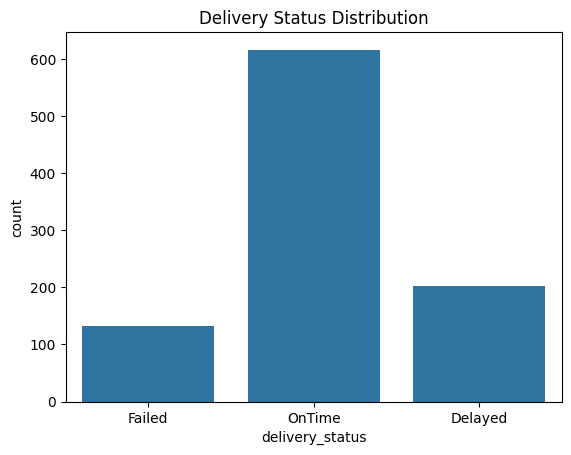

In [14]:
print(deliveries["delivery_status"].value_counts())

sns.countplot(x="delivery_status", data=deliveries)

plt.title("Delivery Status Distribution")

plt.show()

count    936.000000
mean       3.864679
std        0.894420
min        1.000000
25%        3.360000
50%        4.040000
75%        4.550000
max        5.000000
Name: customer_rating_post_delivery, dtype: float64


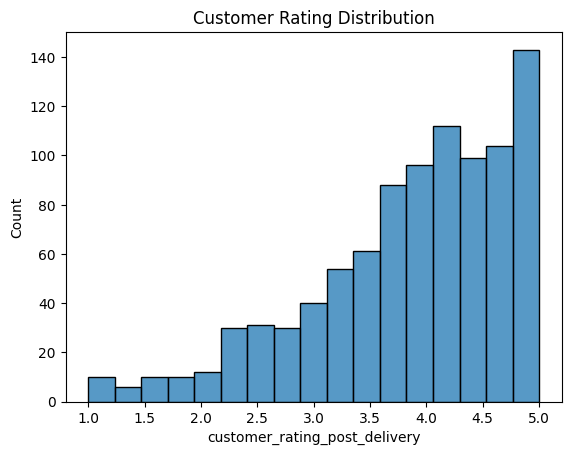

In [15]:
print(deliveries["customer_rating_post_delivery"].describe())

sns.histplot(deliveries["customer_rating_post_delivery"])

plt.title("Customer Rating Distribution")

plt.show()

count    950.000000
mean       0.969474
std        1.093189
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        7.000000
Name: manual_route_override_count, dtype: float64


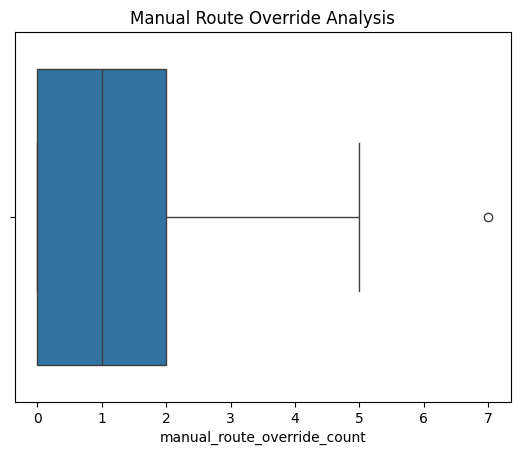

In [16]:
print(deliveries["manual_route_override_count"].describe())

sns.boxplot(x=deliveries["manual_route_override_count"])

plt.title("Manual Route Override Analysis")

plt.show()

count    950.000000
mean      12.841295
std        4.336468
min        2.500000
25%        9.925000
50%       12.645000
75%       15.697500
max       29.430000
Name: fuel_or_charge_cost, dtype: float64


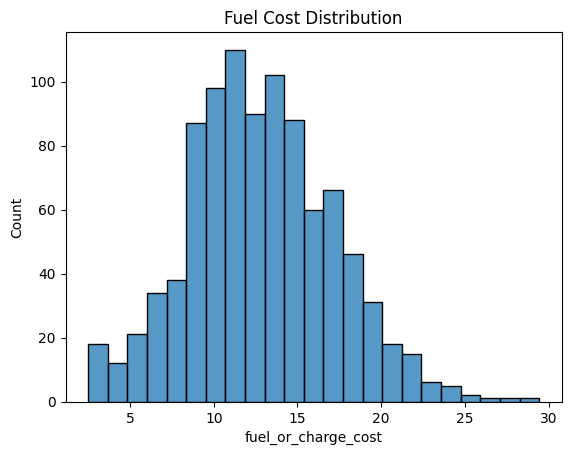

In [17]:
print(deliveries["fuel_or_charge_cost"].describe())

sns.histplot(deliveries["fuel_or_charge_cost"])

plt.title("Fuel Cost Distribution")

plt.show()

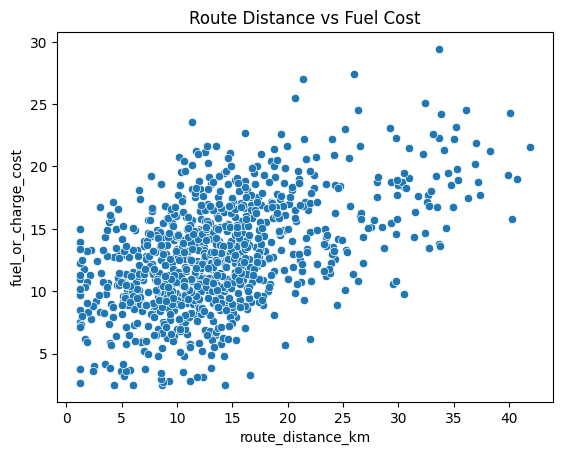

In [18]:
sns.scatterplot(
    x=deliveries["route_distance_km"],
    y=deliveries["fuel_or_charge_cost"]
)

plt.title("Route Distance vs Fuel Cost")

plt.show()

In [19]:
print(complaints.columns)

Index(['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel',
       'severity', 'created_at', 'status', 'resolution_days',
       'compensation_amount'],
      dtype='object')


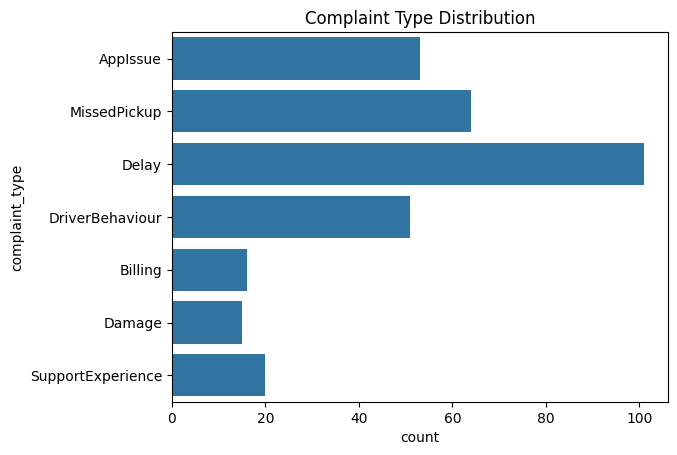

In [20]:
sns.countplot(y="complaint_type", data=complaints)

plt.title("Complaint Type Distribution")

plt.show()

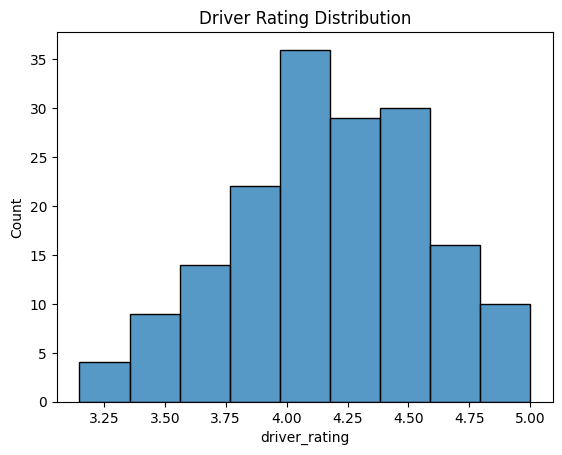

In [21]:
sns.histplot(drivers["driver_rating"])

plt.title("Driver Rating Distribution")

plt.show()

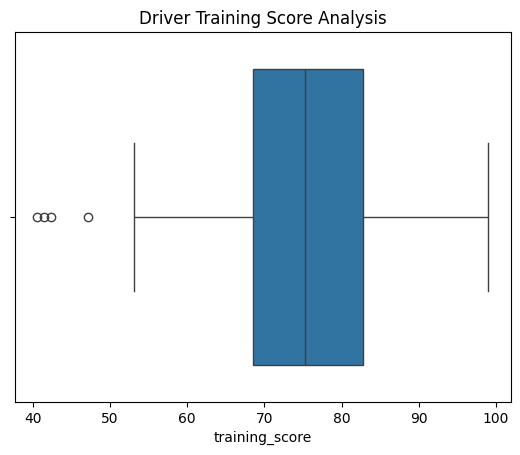

In [22]:
sns.boxplot(x=drivers["training_score"])

plt.title("Driver Training Score Analysis")

plt.show()

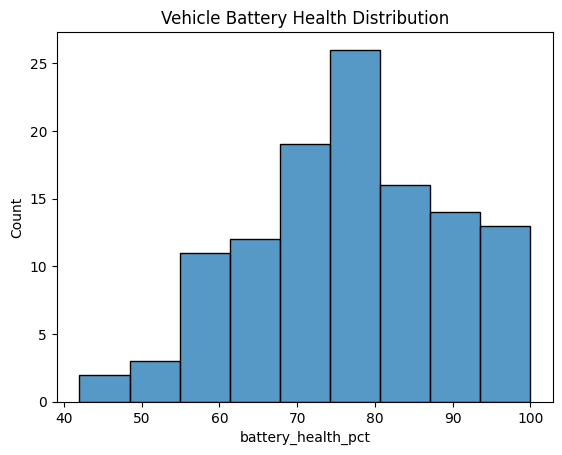

In [23]:
sns.histplot(vehicles["battery_health_pct"])

plt.title("Vehicle Battery Health Distribution")

plt.show()

In [24]:
print(hubs.columns)

Index(['hub_id', 'hub_name', 'zone', 'hub_type', 'capacity_score'], dtype='object')


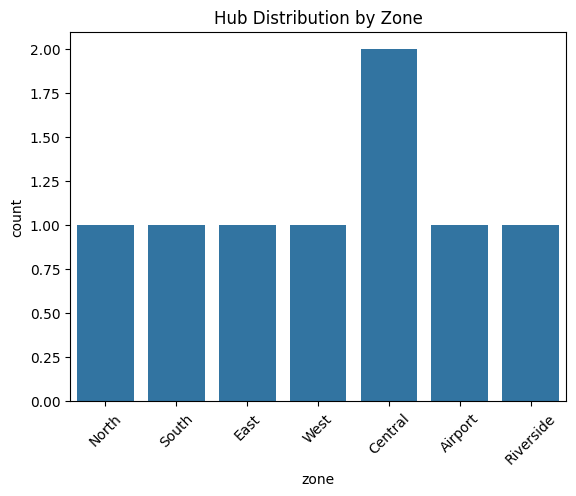

In [27]:
sns.countplot(x="zone", data=hubs)

plt.title("Hub Distribution by Zone")

plt.xticks(rotation=45)

plt.show()

In [28]:
delivery_driver = pd.merge(
    deliveries,
    drivers,
    on="driver_id"
)

print(delivery_driver.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1             

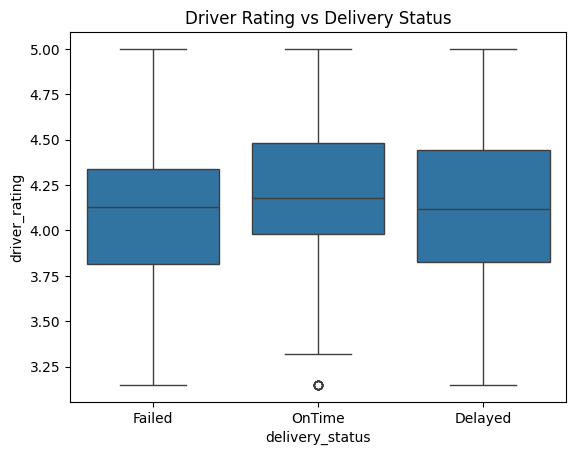

In [29]:
sns.boxplot(
    x="delivery_status",
    y="driver_rating",
    data=delivery_driver
)

plt.title("Driver Rating vs Delivery Status")

plt.show()

In [30]:
delivery_vehicle = pd.merge(
    deliveries,
    vehicles,
    on="vehicle_id"
)

print(delivery_vehicle.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1             

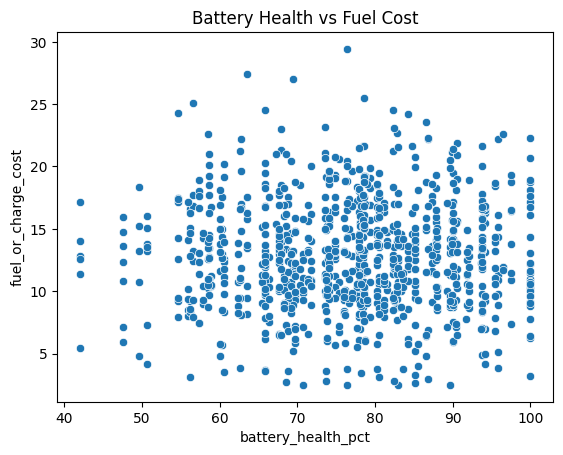

In [31]:
sns.scatterplot(
    x="battery_health_pct",
    y="fuel_or_charge_cost",
    data=delivery_vehicle
)

plt.title("Battery Health vs Fuel Cost")

plt.show()

In [32]:
delivery_hub = pd.merge(
    deliveries,
    hubs,
    on="hub_id"
)

print(delivery_hub.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1             

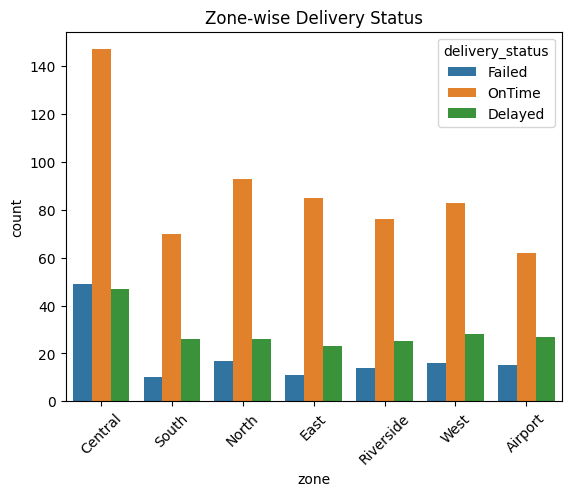

In [33]:
sns.countplot(
    x="zone",
    hue="delivery_status",
    data=delivery_hub
)

plt.title("Zone-wise Delivery Status")

plt.xticks(rotation=45)

plt.show()